## Test CUDA enabled PyTorch environment

Hardware specification:

- **RAM:** 32GB
- **GPU:** NVIDIA RTX 3060 12GB

PyTorch & CUDA versioning:

- **PyTorch:** 2.4.1
- **CUDA TK:** 11.8
- **CuDNN:** 90100

In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA is available.")
else:
    print("CUDA is not available.")
    exit(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    print("Running on GPU:", torch.cuda.get_device_name(0))
else:
    print('Running on CPU')

x = torch.tensor([1, 2, 3]).to(device)
y = torch.tensor([4, 5, 6]).to(device)
z = x + y
print("Result on", device.type, ":", z)

CUDA is available.
Running on GPU: NVIDIA GeForce RTX 3060
Result on cuda : tensor([5, 7, 9], device='cuda:0')


---

### `my_metrics.py` Functions Test

In [2]:
import numpy as np
from my_metrics import (
    binary_accuracy, binary_precision, binary_recall, binary_f1, binary_conf_matrix,
    multiclass_accuracy, multiclass_precision, multiclass_recall, multiclass_f1, multiclass_conf_matrix
)

# Dummy binary classification data
y_true_binary = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
y_pred_binary = np.array([0, 1, 0, 0, 1, 1, 1, 1, 0, 0])

print("Binary Classification Metrics")
print("Accuracy:", binary_accuracy(y_pred_binary, y_true_binary))
print("Precision:", binary_precision(y_pred_binary, y_true_binary))
print("Recall:", binary_recall(y_pred_binary, y_true_binary))
print("F1 Score:", binary_f1(y_pred_binary, y_true_binary))
print("Confusion Matrix:\n", binary_conf_matrix(y_pred_binary, y_true_binary))

# Dummy multiclass classification data
y_true_multi = np.array([0, 1, 2, 1, 2, 0, 1, 2, 0, 1])
y_pred_multi = np.array([0, 2, 2, 1, 0, 0, 1, 2, 1, 1])

print("\nMulticlass Classification Metrics")
print("Accuracy:", multiclass_accuracy(y_pred_multi, y_true_multi))
print("Precision:", multiclass_precision(y_pred_multi, y_true_multi))
print("Recall:", multiclass_recall(y_pred_multi, y_true_multi))
print("F1 Score:", multiclass_f1(y_pred_multi, y_true_multi))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_pred_multi, y_true_multi))

Binary Classification Metrics
Accuracy: 0.8
Precision: 0.8
Recall: 0.8
F1 Score: 0.8000000000000002
Confusion Matrix:
 [[4 1]
 [1 4]]

Multiclass Classification Metrics
Accuracy: 0.7
Precision: [0.6666666666666666, 0.75, 0.6666666666666666]
Recall: [0.6666666666666666, 0.75, 0.6666666666666666]
F1 Score: [0.6666666666666666, 0.75, 0.6666666666666666]
Confusion Matrix:
 [[2 1 0]
 [0 3 1]
 [1 0 2]]


---

### Feedforward Neural Network on dummy data

Architecture:

- Inputs
- FullyConnected (128, ReLU)
- FullyConnected (128, ReLU)
- Outputs (10, Softmax)

Model:

- Optim: BGD
- LR: 0.01
- Loss: Cross-Entropy

In [3]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.lr = lr
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, hidden_size) * 0.01
        self.b2 = np.zeros((1, hidden_size))
        self.W3 = np.random.randn(hidden_size, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def cross_entropy(self, y_pred, y_true):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.softmax(self.z3)
        return self.a3

    def backward(self, X, y_true):
        m = y_true.shape[0]
        dz3 = self.a3 - y_true
        dW3 = (self.a2.T @ dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        da2 = dz3 @ self.W3.T
        dz2 = da2 * (self.z2 > 0)
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.z1 > 0)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        batch_size = 32
        y_one_hot = np.eye(np.max(y) + 1)[y]
        num_batches = len(X) // batch_size
        for _ in range(epochs):
            indices = np.random.permutation(len(X))
            X_shuffled = X[indices]
            y_one_hot_shuffled = y_one_hot[indices]
            for i in range(num_batches):
                start_index = i * batch_size
                end_index = (i + 1) * batch_size if (i + 1) * batch_size <= len(X) else len(X)
                y_pred = self.forward(X_shuffled[start_index:end_index])
                loss = self.cross_entropy(y_pred, y_one_hot_shuffled[start_index:end_index])
                self.backward(X_shuffled[start_index:end_index], y_one_hot_shuffled[start_index:end_index])


    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

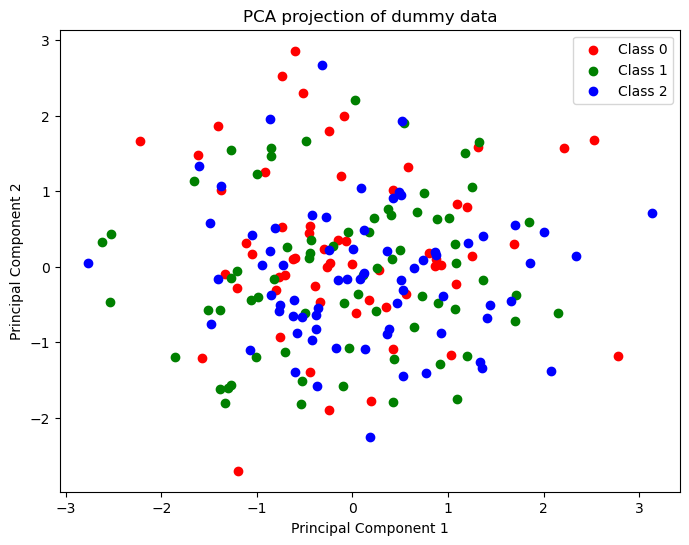


Dummy Classification Metrics
Overall Accuracy: 0.355
Per-Class Precision: [0, 0, 0.355]
Per-Class Recall: [0.0, 0.0, 1.0]
Per-Class F1 Score: [0, 0, 0.5239852398523985]
Confusion Matrix:
 [[ 0  0 59]
 [ 0  0 70]
 [ 0  0 71]]


In [5]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

np.random.seed(0)
N, D, C = 200, 4, 3
X_dummy = np.random.randn(N, D)
y_dummy = np.random.randint(C, size=N)

encoder = OneHotEncoder()
Y = encoder.fit_transform(y_dummy[:, np.newaxis]).toarray()
colors = ['r', 'g', 'b']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dummy)

plt.figure(figsize=(8,6))
for c, i in enumerate(np.unique(y_dummy)):
    plt.scatter(X_pca[Y[:,c] == 1, 0], X_pca[Y[:,c] == 1, 1], color = colors[c])
plt.legend(['Class '+str(i) for i in np.unique(y_dummy)])
plt.title('PCA projection of dummy data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

mlp = MLP(D, 128, C, lr=0.01)
mlp.train(X_dummy, y_dummy, epochs=1000)
y_pred_dummy = mlp.predict(X_dummy)

print("\nDummy Classification Metrics")
print("Overall Accuracy:", multiclass_accuracy(y_pred_dummy, y_dummy))
print("Per-Class Precision:", multiclass_precision(y_pred_dummy, y_dummy))
print("Per-Class Recall:", multiclass_recall(y_pred_dummy, y_dummy))
print("Per-Class F1 Score:", multiclass_f1(y_pred_dummy, y_dummy))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_pred_dummy, y_dummy))

---

### Feedforward Neural Network on CIFAR-10

Architecture:

- Inputs
- FullyConnected (128, ReLU)
- FullyConnected (128, ReLU)
- Outputs (10, Softmax)

Model:

- Optim: BGD
- LR: 0.01
- Loss: Cross-Entropy

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import pickle
import numpy as np
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PyTorchMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

def load_cifar10_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    X = torch.tensor(batch[b'data'].reshape(-1, 3 * 32 * 32) / 255.0, dtype=torch.float32).to(device)
    y = torch.tensor(batch[b'labels'], dtype=torch.long).to(device)
    return X, y

def load_cifar10(data_dir):
    X_train, y_train = [], []
    for i in range(1, 6):
        X, y = load_cifar10_batch(os.path.join(data_dir, f'data_batch_{i}'))
        X_train.append(X)
        y_train.append(y)
    X_train = torch.cat(X_train)
    y_train = torch.cat(y_train)
    X_test, y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))
    return X_train, y_train, X_test, y_test

data_dir = 'data/cifar10/cifar-10-batches-py'
X_cifar_train, y_cifar_train, X_cifar_test, y_cifar_test = load_cifar10(data_dir)

train_loader = DataLoader(TensorDataset(X_cifar_train, y_cifar_train), batch_size=32, shuffle=True)

model = PyTorchMLP(3072, 128, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

def train(model, train_loader, epochs=1000):
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {correct/total:.4f}")

def predict(model, X):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        return torch.argmax(outputs, dim=1)

train(model, train_loader, epochs=100)
y_cifar_pred = predict(model, X_cifar_test).cpu().numpy()
y_cifar_test = y_cifar_test.cpu().numpy()

print("\nCIFAR-10 Classification Metrics")
print("Overall Accuracy:", multiclass_accuracy(y_cifar_pred, y_cifar_test))
print("Per-Class Precision:", multiclass_precision(y_cifar_pred, y_cifar_test))
print("Per-Class Recall:", multiclass_recall(y_cifar_pred, y_cifar_test))
print("Per-Class F1 Score:", multiclass_f1(y_cifar_pred, y_cifar_test))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_cifar_pred, y_cifar_test))

Epoch 10/100, Loss: 1.4505, Accuracy: 0.4865
Epoch 20/100, Loss: 1.2822, Accuracy: 0.5440
Epoch 30/100, Loss: 1.1677, Accuracy: 0.5852
Epoch 40/100, Loss: 1.0755, Accuracy: 0.6187
Epoch 50/100, Loss: 0.9954, Accuracy: 0.6502
Epoch 60/100, Loss: 0.9201, Accuracy: 0.6753
Epoch 70/100, Loss: 0.8541, Accuracy: 0.6979
Epoch 80/100, Loss: 0.7900, Accuracy: 0.7213
Epoch 90/100, Loss: 0.7350, Accuracy: 0.7393
Epoch 100/100, Loss: 0.6771, Accuracy: 0.7604

CIFAR-10 Classification Metrics
Overall Accuracy: 0.5175
Per-Class Precision: [0.6994219653179191, 0.6873479318734793, 0.4324970131421744, 0.32916340891321344, 0.41739824421388666, 0.3961352657004831, 0.5828282828282828, 0.5795339412360689, 0.6547497446373851, 0.5506216696269982]
Per-Class Recall: [0.484, 0.565, 0.362, 0.421, 0.523, 0.41, 0.577, 0.572, 0.641, 0.62]
Per-Class F1 Score: [0.5721040189125296, 0.6201975850713503, 0.39412084921066953, 0.36946028960070204, 0.4642698624056813, 0.40294840294840295, 0.5798994974874372, 0.57574232511323

---

### Convolutional Neural Network on MNIST

- **FNN Architecture:** Similar to Dummy and CIFAR-10 case
- **CNN Architecture:**
    - Conv2D (32, 5, 5)
    - MaxPool (2, 2)
    - Conv2D (48, 5, 5)
    - MaxPool (2, 2)
    - Flatten
    - FullyConnected (512, ReLU)
    - Outputs (10, Softmax)

**Requirement:** Test both FNN and CNN on the MNIST dataset

In [14]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

def load_mnist():
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X, y = mnist.data.astype("float32"), mnist.target.astype("int64")
    X /= 255.0
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = load_mnist()
X_mnist_train, X_mnist_test = torch.tensor(X_mnist_train), torch.tensor(X_mnist_test)
y_mnist_train, y_mnist_test = torch.tensor(y_mnist_train), torch.tensor(y_mnist_test)

train_loader = DataLoader(TensorDataset(X_mnist_train, y_mnist_train), batch_size=32, shuffle=True)

model = PyTorchMLP(784, 128, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train(model, train_loader, epochs=20)
y_mnist_pred = predict(model, X_mnist_test).cpu().numpy()
y_mnist_test = y_mnist_test.cpu().numpy()

print("\nMNIST Classification Metrics")
print("Overall Accuracy:", multiclass_accuracy(y_mnist_pred, y_mnist_test))
print("Per-Class Precision:", multiclass_precision(y_mnist_pred, y_mnist_test))
print("Per-Class Recall:", multiclass_recall(y_mnist_pred, y_mnist_test))
print("Per-Class F1 Score:", multiclass_f1(y_mnist_pred, y_mnist_test))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_mnist_pred, y_mnist_test))

E:\Miniconda\envs\pt_gpu_env\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Epoch 10/20, Loss: 0.1580, Accuracy: 0.9537
Epoch 20/20, Loss: 0.0800, Accuracy: 0.9769

MNIST Classification Metrics
Overall Accuracy: 0.9670714285714286
Per-Class Precision: [0.9879245283018868, 0.9722735674676525, 0.9618705035971223, 0.9582463465553236, 0.9695787831513261, 0.9675376088677752, 0.9743223965763196, 0.9700598802395209, 0.9612518628912071, 0.9483600837404047]
Per-Class Recall: [0.9746835443037974, 0.98625, 0.9688405797101449, 0.9609211444521982, 0.9598455598455599, 0.959937156323645, 0.9785100286532952, 0.9700598802395209, 0.9506263817243921, 0.9570422535211267]
Per-Class F1 Score: [0.9812593703148426, 0.9792119143654979, 0.9653429602888086, 0.9595818815331011, 0.9646876212650368, 0.9637223974763408, 0.9764117226590423, 0.9700598802395209, 0.955909596146721, 0.9526813880126183]
Confusion Matrix:
 [[1309    1    5    1    2    4    7    4    8    2]
 [   0 1578    5    4    2    0    0    5    5    1]
 [   1    9 1337    5    2    3    4    7   10    2]
 [   1    3   15 1

In [18]:
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import torch
import torch.nn as nn
import torch.optim as optim

# Load MNIST
def load_mnist():
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X, y = mnist.data.reshape(-1, 1, 28, 28).astype("float32"), mnist.target.astype("int64")
    X /= 255.0  # Normalize pixel values to [0, 1]
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = load_mnist()
X_mnist_train, X_mnist_test = torch.tensor(X_mnist_train), torch.tensor(X_mnist_test)
y_mnist_train, y_mnist_test = torch.tensor(y_mnist_train), torch.tensor(y_mnist_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(TensorDataset(X_mnist_train, y_mnist_train), batch_size=32, shuffle=True)

# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 48, kernel_size=5, stride=1, padding=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(48 * 7 * 7, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

def train(model, train_loader, epochs=100):
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {correct/total:.4f}")

def predict(model, X):
    model.eval()
    with torch.no_grad():
        outputs = model(X.to(device))
        return torch.argmax(outputs, dim=1)

train(model, train_loader, epochs=10)
y_mnist_pred = predict(model, X_mnist_test).cpu().numpy()
y_mnist_test = y_mnist_test.cpu().numpy()

# Evaluation Metrics
print("\nMNIST Classification Metrics")
print("Overall Accuracy:", multiclass_accuracy(y_mnist_pred, y_mnist_test))
print("Per-Class Precision:", multiclass_precision(y_mnist_pred, y_mnist_test))
print("Per-Class Recall:", multiclass_recall(y_mnist_pred, y_mnist_test))
print("Per-Class F1 Score:", multiclass_f1(y_mnist_pred, y_mnist_test))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_mnist_pred, y_mnist_test))

Epoch 1/10, Loss: 0.6787, Accuracy: 0.7963
Epoch 2/10, Loss: 0.1477, Accuracy: 0.9551
Epoch 3/10, Loss: 0.0941, Accuracy: 0.9708
Epoch 4/10, Loss: 0.0715, Accuracy: 0.9781
Epoch 5/10, Loss: 0.0595, Accuracy: 0.9815
Epoch 6/10, Loss: 0.0512, Accuracy: 0.9840
Epoch 7/10, Loss: 0.0457, Accuracy: 0.9856
Epoch 8/10, Loss: 0.0398, Accuracy: 0.9878
Epoch 9/10, Loss: 0.0368, Accuracy: 0.9886
Epoch 10/10, Loss: 0.0326, Accuracy: 0.9897

MNIST Classification Metrics
Overall Accuracy: 0.9867142857142858
Per-Class Precision: [0.992553983618764, 0.9900559353635798, 0.9675828047921071, 0.9895031490552834, 0.981637337413925, 0.9952418715305313, 0.9907341411261582, 0.9912398921832885, 0.9850634802091113, 0.9836415362731152]
Per-Class Recall: [0.992553983618764, 0.995625, 0.994927536231884, 0.9867411025819958, 0.9907335907335907, 0.98586017282011, 0.995702005730659, 0.978709248170326, 0.971997052321297, 0.973943661971831]
Per-Class F1 Score: [0.992553983618764, 0.9928326581489559, 0.9810646659521257, 0

---

### Bonus: CNN on CIFAR-10

In [21]:
class CNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=5, stride=1, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 48, kernel_size=5, stride=1, padding=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(48 * 7 * 7 if in_channels == 1 else 48 * 8 * 8, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def load_cifar10_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    X = torch.tensor(batch[b'data'].reshape(-1, 3, 32, 32) / 255.0, dtype=torch.float32).to(device)
    y = torch.tensor(batch[b'labels'], dtype=torch.long).to(device)
    return X, y

def load_cifar10(data_dir):
    X_train, y_train = [], []
    for i in range(1, 6):
        X, y = load_cifar10_batch(os.path.join(data_dir, f'data_batch_{i}'))
        X_train.append(X)
        y_train.append(y)
    X_train = torch.cat(X_train)
    y_train = torch.cat(y_train)
    X_test, y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))
    return X_train, y_train, X_test, y_test

data_dir = 'data/cifar10/cifar-10-batches-py'
X_cifar_train, y_cifar_train, X_cifar_test, y_cifar_test = load_cifar10(data_dir)

train_loader_cifar = DataLoader(TensorDataset(X_cifar_train, y_cifar_train), batch_size=32, shuffle=True)

model_cifar = CNN(in_channels=3).to(device)
optimizer = optim.SGD(model_cifar.parameters(), lr=0.01)

train(model_cifar, train_loader_cifar, epochs=25)
y_cifar_pred = predict(model_cifar, X_cifar_test).cpu().numpy()
y_cifar_test = y_cifar_test.cpu().numpy()

print("\nCIFAR-10 Classification Metrics")
print("Overall Accuracy:", multiclass_accuracy(y_cifar_pred, y_cifar_test))
print("Per-Class Precision:", multiclass_precision(y_cifar_pred, y_cifar_test))
print("Per-Class Recall:", multiclass_recall(y_cifar_pred, y_cifar_test))
print("Per-Class F1 Score:", multiclass_f1(y_cifar_pred, y_cifar_test))
print("Confusion Matrix:\n", multiclass_conf_matrix(y_cifar_pred, y_cifar_test))

Epoch 1/25, Loss: 2.0090, Accuracy: 0.2719
Epoch 2/25, Loss: 1.6249, Accuracy: 0.4167
Epoch 3/25, Loss: 1.4448, Accuracy: 0.4826
Epoch 4/25, Loss: 1.3359, Accuracy: 0.5259
Epoch 5/25, Loss: 1.2474, Accuracy: 0.5580
Epoch 6/25, Loss: 1.1619, Accuracy: 0.5907
Epoch 7/25, Loss: 1.0824, Accuracy: 0.6183
Epoch 8/25, Loss: 1.0080, Accuracy: 0.6470
Epoch 9/25, Loss: 0.9372, Accuracy: 0.6718
Epoch 10/25, Loss: 0.8764, Accuracy: 0.6954
Epoch 11/25, Loss: 0.8137, Accuracy: 0.7185
Epoch 12/25, Loss: 0.7517, Accuracy: 0.7386
Epoch 13/25, Loss: 0.6943, Accuracy: 0.7569
Epoch 14/25, Loss: 0.6338, Accuracy: 0.7808
Epoch 15/25, Loss: 0.5751, Accuracy: 0.8007
Epoch 16/25, Loss: 0.5158, Accuracy: 0.8227
Epoch 17/25, Loss: 0.4552, Accuracy: 0.8450
Epoch 18/25, Loss: 0.3948, Accuracy: 0.8654
Epoch 19/25, Loss: 0.3386, Accuracy: 0.8870
Epoch 20/25, Loss: 0.2848, Accuracy: 0.9062
Epoch 21/25, Loss: 0.2280, Accuracy: 0.9284
Epoch 22/25, Loss: 0.1821, Accuracy: 0.9432
Epoch 23/25, Loss: 0.1443, Accuracy: 0.95

**Comment:** Overfitting